In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
from scipy.stats.mstats import gmean

import matplotlib.ticker as mtick 

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

#import weightedcalcs as wc
#import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

In [20]:
country_list = pd.read_csv("C:\\github\\median-tariff\\data\\country-list-20.csv", header=None, names=["CTY_CODE"])

In [85]:
def make_tariff_country_date(dfcntry, date):
   
   bar = dfcntry[(dfcntry['time'] == date)].copy()

   bar["tariff"] = bar["CAL_DUT_MO"] / bar["CON_VAL_MO"]

   bar = bar[["I_COMMODITY", "CON_VAL_MO", "CAL_DUT_MO", "tariff", "CTY_NAME"]]

   return bar

In [77]:
def make_good_country_year(dfcntry, year):
    """
    Process country data for a specific year and calculate aggregate metrics.
    
    Parameters:
    -----------
    dfcntry : pandas.DataFrame
        DataFrame containing country trade data with columns:
        - time: datetime
        - I_COMMODITY: commodity code
        - CON_VAL_MO: consumption value
        - CAL_DUT_MO: calculated duty
        - CTY_NAME: country name
    year : str
        Year to filter data (e.g., "2024")
    
    Returns:
    --------
    pandas.DataFrame
        Aggregated data by commodity for the specified year
    """
    # Filter to specific year
    df_year = dfcntry[dfcntry['time']== year]
    
    # Group by commodity and aggregate
    grp = df_year.groupby("I_COMMODITY")
    
    result = grp.agg({
        "CON_VAL_MO": "sum",
        "CAL_DUT_MO": "sum",
        "CTY_NAME": "first"})
    
    
    return result

In [78]:
country_list.head()

,CTY_CODE
0,5700
1,2010
2,1220
3,5880
4,4280


In [197]:
def process_countries_for_date(country_list, target_date, weight_year="2024", selected_country=None):
    """
    Process multiple countries and create combined dataset with weights.
    
    Parameters:
    -----------
    country_list : pandas.DataFrame or list
        DataFrame with CTY_CODE column or list of country codes
    target_date : str
        Date to extract tariff data for (e.g., "2025-08")
    weight_year : str, optional
        Year to use for calculating weights (default: "2024")
    selected_country : str, optional
        Country name to filter results (e.g., "CANADA"). If None, returns all countries (default: None)
    
    Returns:
    --------
    pandas.DataFrame
        Combined dataframe with tariff data and weights for all countries (or selected country)
    """
    # Handle both DataFrame and list inputs
    if isinstance(country_list, pd.DataFrame):
        countries = country_list.CTY_CODE
    else:
        countries = country_list
    
    all_results = []
    tariff_results = []
    
    for country in countries:
        
        file = f"C:\\github\\median-tariff\\data\\imports-hs10\\{country}data-2024-12.parquet"
        
        # Load country data
        dfcntry = pq.read_table(file).to_pandas()
        
        dfcntry["CAL_DUT_MO"] = dfcntry["CAL_DUT_MO"].astype(float)

        dfcntry["CON_VAL_MO"] = dfcntry["CON_VAL_MO"].astype(float)

        dfcntry.time = pd.to_datetime(dfcntry.time, format="%Y-%m")

        dfcntry["applied_tariff"] = dfcntry["CAL_DUT_MO"] / dfcntry["CON_VAL_MO"]
            
        # Calculate metrics for weight year
        results_df = make_good_country_year(dfcntry, weight_year)

        results_df.reset_index(inplace=True)
        
        # Get tariff data for target date
        tariff_df = make_tariff_country_date(dfcntry, target_date)

        tariff_df.reset_index(drop=True, inplace=True)
        
        # Add to lists
        all_results.append(results_df)

        tariff_results.append(tariff_df)
        
        #print(f"Processed {country}: {results_df['CTY_NAME'].iloc[0]}")
    
    # Combine all results into one dataframe
    combined_results = pd.concat(all_results)
    combined_results.reset_index(drop=True, inplace=True)
    
    combined_tariff_results = pd.concat(tariff_results)
    combined_tariff_results.reset_index(drop=True, inplace=True)
    
    # Calculate weights
    combined_results["weights"] = combined_results["CON_VAL_MO"] / combined_results["CON_VAL_MO"].sum()
    
    # Merge weights with tariff data
    bigdf = pd.merge(
        combined_results[["I_COMMODITY", "CTY_NAME", "weights"]], 
        combined_tariff_results, 
        how="left", 
        on=["I_COMMODITY", "CTY_NAME"]
    )
    
    # Filter to selected country if specified
    if selected_country is not None:
        bigdf = bigdf[bigdf["CTY_NAME"] == selected_country].copy()
        # Renormalize weights to sum to 1 for the selected country
        bigdf["weights"] = bigdf["weights"] / bigdf["weights"].sum()
    
    return bigdf

In [192]:
bigdf = process_countries_for_date(country_list, "2025-08", weight_year="2024")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted RMS Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

# print(" ")

# varcomponent = (  1.0 + (bigdf["weights"] * ((bigdf["tariff"] - meanweighted) / meanweighted)**2).sum()  )**0.5

# altmeasure = meanweighted * varcomponent

# print(f"Alternative Decomposition: {altmeasure:.2%}")

# print(" ")

# print(f"Variance Component: {varcomponent:.4f}")

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

Weighted RMS Tariff: 21.63%
 
Weighted Mean Tariff: 13.28%
 
Simple Mean Tariff: 11.00%


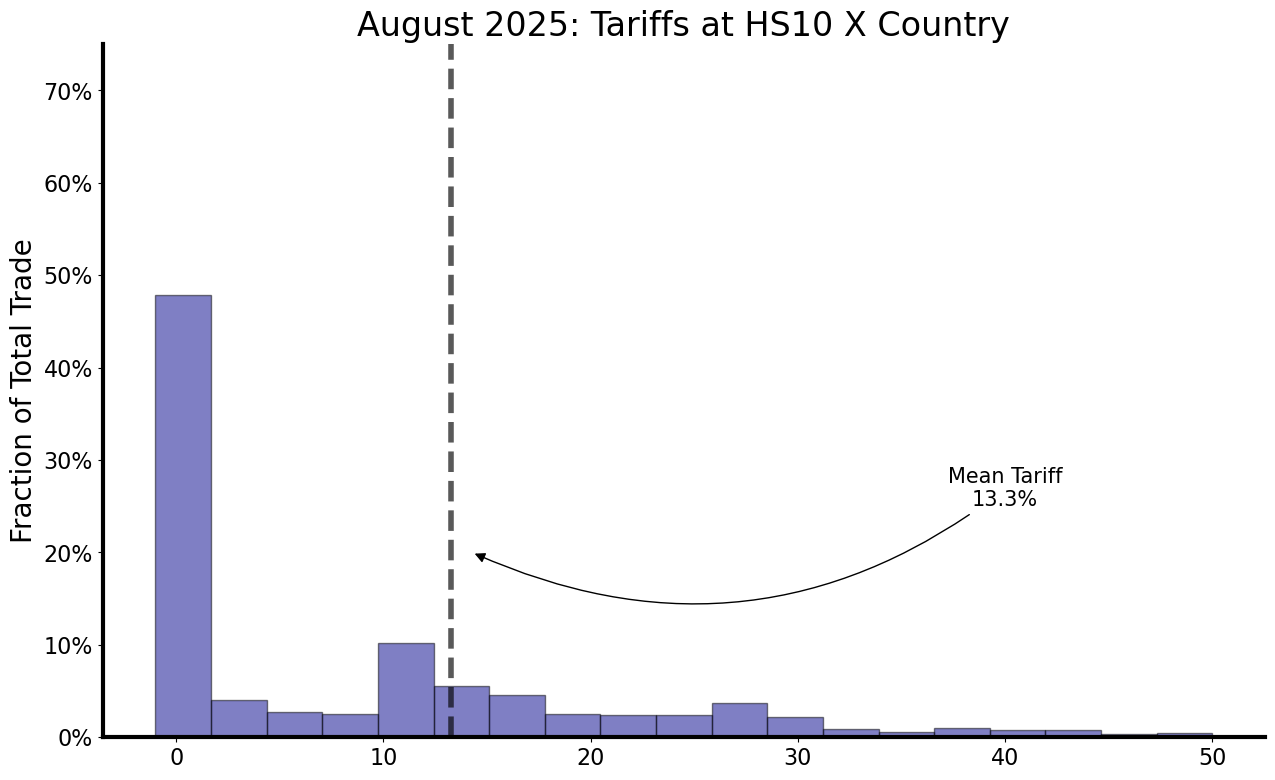

In [ ]:
fig, ax = plt.subplots(figsize = (15,9))

# fig = plt.figure(figsize=(15, 9))
# bax_ax = bax.brokenaxes(ylims=((0, 0.20), (0.40, 0.50)), hspace=.05)

bin_edges = np.linspace(-1, 50, 20)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(100*bigdf["tariff"], bin_edges) - 1

# Sum CON_VAL_MO in each bin
bin_sums = np.zeros(len(bin_edges) - 1)

for i in range(len(bin_sums)):

    bin_sums[i] = bigdf.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MO
fractions = bin_sums / bigdf["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), 
       align='edge', color='darkblue', alpha=0.5, edgecolor='black')

# ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("August 2025: Tariffs at HS10 X Country", fontsize = 24)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

# mediantariff = foo["applied_tariff"].median()

# ax.vlines(mediantariff, 0, 0.75, 
#           linestyles= "dashed", color = "k", linewidth=4, alpha=0.65)

# ax.annotate("Median Tariff\n{:.1f}%".format(mediantariff), 
#             xy=(mediantariff+1, 0.3), 
#             xytext=(30, 0.45),
#             arrowprops={
#             "arrowstyle": "-|>", # This is stuff about the arrow
#             "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
#             "color": "black"},
#             fontsize=15, color='black',
#             ha='center')


ax.vlines(100*meanweighted, 0, 0.75, 
          linestyles= "dashed", color = "k", linewidth=4, alpha=0.65)

ax.annotate("Mean Tariff\n{:.1f}%".format(100*meanweighted), 
            xy=(100*meanweighted+1, 0.20), 
            xytext=(40, 0.25),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

ax.set_ylim(top=0.85)

# plt.savefig(figfile+"aug2025-histogram.png", bbox_inches = "tight")

# plt.savefig(figfile+"aug2025-histogram.pdf", bbox_inches = "tight")

plt.show()

In [193]:
bigdf = process_countries_for_date(country_list, "2024-08", weight_year="2024")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted RMS Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

# print(" ")

# varcomponent = (  1.0 + (bigdf["weights"] * ((bigdf["tariff"] - meanweighted) / meanweighted)**2).sum()  )**0.5

# altmeasure = meanweighted * varcomponent

# print(f"Alternative Decomposition: {altmeasure:.2%}")

# print(" ")

# print(f"Variance Component: {varcomponent:.4f}")

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

Weighted RMS Tariff: 7.24%
 
Weighted Mean Tariff: 2.71%
 
Simple Mean Tariff: 2.70%


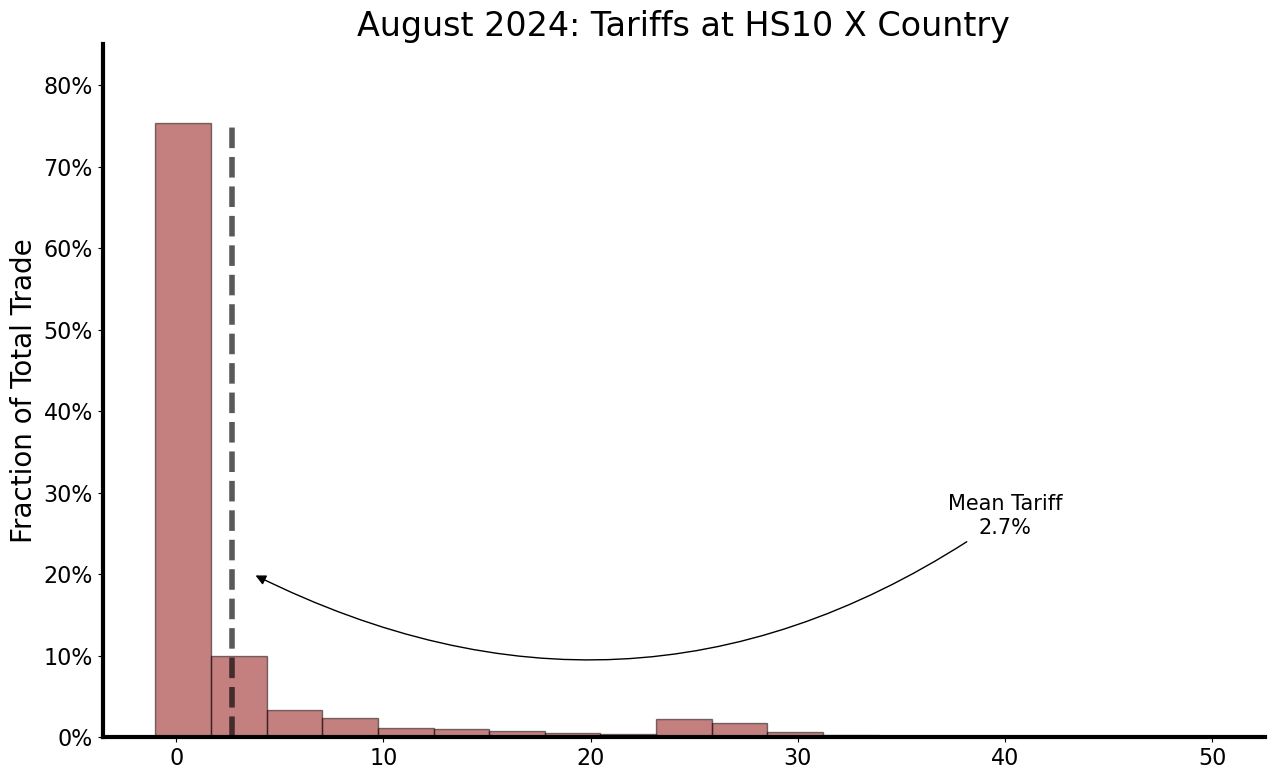

In [196]:
fig, ax = plt.subplots(figsize = (15,9))

# fig = plt.figure(figsize=(15, 9))
# bax_ax = bax.brokenaxes(ylims=((0, 0.20), (0.40, 0.50)), hspace=.05)

bin_edges = np.linspace(-1, 50, 20)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(100*bigdf["tariff"], bin_edges) - 1

# Sum CON_VAL_MO in each bin
bin_sums = np.zeros(len(bin_edges) - 1)

for i in range(len(bin_sums)):

    bin_sums[i] = bigdf.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MO
fractions = bin_sums / bigdf["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), 
       align='edge', color='darkred', alpha=0.5, edgecolor='black')



ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("August 2024: Tariffs at HS10 X Country", fontsize = 24)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

# mediantariff = foo["applied_tariff"].median()

# ax.vlines(mediantariff, 0, 0.75, 
#           linestyles= "dashed", color = "k", linewidth=4, alpha=0.65)

# ax.annotate("Median Tariff\n{:.1f}%".format(mediantariff), 
#             xy=(mediantariff+1, 0.3), 
#             xytext=(30, 0.45),
#             arrowprops={
#             "arrowstyle": "-|>", # This is stuff about the arrow
#             "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
#             "color": "black"},
#             fontsize=15, color='black',
#             ha='center')


ax.vlines(100*meanweighted, 0, 0.75, 
          linestyles= "dashed", color = "k", linewidth=4, alpha=0.65)

ax.annotate("Mean Tariff\n{:.1f}%".format(100*meanweighted), 
            xy=(100*meanweighted+1, 0.20), 
            xytext=(40, 0.25),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

ax.set_ylim(top=0.85)

# plt.savefig(figfile+"aug2025-histogram.png", bbox_inches = "tight")

# plt.savefig(figfile+"aug2025-histogram.pdf", bbox_inches = "tight")

plt.show()

In [ ]:
bigdf = process_countries_for_date(country_list, "2025-02", weight_year="2024", selected_country="CHINA")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted RMS Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

Weighted RMS Tariff: 17.93%
 
Weighted Mean Tariff: 13.75%
 
Simple Mean Tariff: 12.83%
